<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/RNN_Increasing_Numbers_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Objective

Predict the next number in the sequence.

Dataset:

Input	Output:

5 10 15- 20

10 15 20-	25

15 20 25-	30

20 25 30-	35

25 30 35-	40

30 35 40-	45

35 40 45-	50

40 45 50-	55

Later, we'll test:

45 50 55 → ?
Expected = 60

In [ ]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
X = np.array([
    [5,10,15],
    [10,15,20],
    [15,20,25],
    [20,25,30],
    [25,30,35],
    [30,35,40],
    [35,40,45],
    [40,45,50]
])

y = np.array([
    20,
    25,
    30,
    35,
    40,
    45,
    50,
    55
])

In [ ]:
X = X / 100
y = y / 100

In [ ]:
X = X.reshape((X.shape[0], X.shape[1], 1))

print(X.shape)

(8, 3, 1)


In [ ]:
model = Sequential([
    SimpleRNN(
        64,
        activation="tanh",
        input_shape=(3,1)
    ),
    Dense(32, activation="relu"),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:
history = model.fit(
    X,
    y,
    epochs=200,
    verbose=0
)

In [ ]:
test = np.array([[45,50,55]])

test = test / 100

test = test.reshape((1,3,1))

prediction = model.predict(test)

print("Predicted Number :", prediction[0][0] * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
Predicted Number : 59.288563


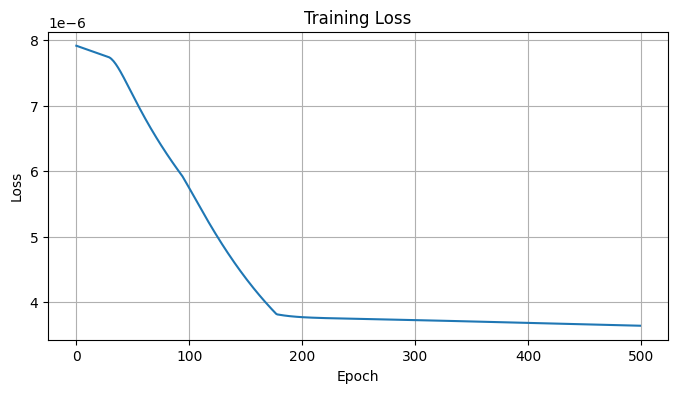

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(history.history["loss"])

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [ ]:
pred = model.predict(X)

print("Actual\tPredicted")

for actual, predicted in zip(y * 100, pred * 100):
    print(f"{actual:.0f}\t{predicted[0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
Actual	Predicted
20	19.73
25	24.95
30	30.11
35	35.20
40	40.22
45	45.14
50	49.97
55	54.69
